# Clone Repository

In [ ]:
!rm -rf HaYOLO
!git clone -b gsconvns-fix --single-branch https://github.com/hilmizr/HaYOLO.git

Cloning into 'HaYOLO'...
remote: Enumerating objects: 38887, done.
remote: Total 38887 (delta 0), reused 0 (delta 0), pack-reused 38887 (from 1)
Receiving objects: 100% (38887/38887), 23.17 MiB | 10.45 MiB/s, done.
Resolving deltas: 100% (28288/28288), done.


In [ ]:
!git pull

fatal: not a git repository (or any of the parent directories): .git


# Install Libraries

In [ ]:
!pip install roboflow gdown thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 134.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

# Import Libraries

In [ ]:
import os
import shutil
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from IPython.display import display
from PIL import Image
import cv2
import json
from shutil import copyfile
import sys
import os
import requests
from pathlib import Path
import random
import pathlib

# Setup Custom YOLO

In [ ]:
sys.path.append("/content/HaYOLO")
# Import YOLO directly from the ultralytics packagea
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics.models import yolo
from ultralytics.nn.modules import GSConv, C3Ghost, CBAM, GSConvns, GSBottleneck, GSBottleneckC, VoVGSCSP, VoVGSCSPC, ASPP, RFB, C3GS, C3k2GS, C3k2Ghost
from ultralytics.nn.modules import C2PSAGhost, C2PSAGS, C2fPSAGhost, C2fPSAGS, C2PSACBAM, C2fPSACBAM

## Define Custom Architecture

In [ ]:
#customize iPython writefile so we can write variables
from IPython.core.magic import register_line_cell_magic
@register_line_cell_magic
def writetemplate(line, cell):
    with open(line, 'w') as f:
        f.write(cell.format(**globals()))

In [ ]:
# ["yolov11n_baseline", "yolov11n_cbam_c3k2ghost", "yolov11n_cbam_ghostconv_c3k2ghost", "yolov11n_cbam_ghostconv", "yolov11n_cbam"]
model_name = "yolov11n_CBAM"
yaml_path = f"/content/HaYOLO/custom_yaml/final_variants/{model_name}.yaml"

In [ ]:
%%writetemplate {yaml_path}
# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# Ultralytics YOLO11 object detection model with P3/8 - P5/32 outputs
# Model docs: https://docs.ultralytics.com/models/yolo11
# Task docs: https://docs.ultralytics.com/tasks/detect

# Parameters
nc: 80 # number of classes
scales: # model compound scaling constants, i.e. 'model=yolo11n.yaml' will call yolo11.yaml with scale 'n'
  # [depth, width, max_channels]
  n: [0.50, 0.25, 1024] # summary: 181 layers, 2624080 parameters, 2624064 gradients, 6.6 GFLOPs
  s: [0.50, 0.50, 1024] # summary: 181 layers, 9458752 parameters, 9458736 gradients, 21.7 GFLOPs
  m: [0.50, 1.00, 512] # summary: 231 layers, 20114688 parameters, 20114672 gradients, 68.5 GFLOPs
  l: [1.00, 1.00, 512] # summary: 357 layers, 25372160 parameters, 25372144 gradients, 87.6 GFLOPs
  x: [1.00, 1.50, 512] # summary: 357 layers, 56966176 parameters, 56966160 gradients, 196.0 GFLOPs

# YOLO11n backbone
backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]] # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]] # 1-P2/4
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]] # 3-P3/8
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Conv, [512, 3, 2]] # 5-P4/16
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]] # 7-P5/32
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]] # 9
  - [-1, 2, CBAM, [256]] # 10

# YOLO11n head
head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]] # cat backbone P4
  - [-1, 2, C3k2, [512, False]] # 13

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]] # cat backbone P3
  - [-1, 2, C3k2, [256, False]] # 16 (P3/8-small)

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]] # cat head P4
  - [-1, 2, C3k2, [512, False]] # 19 (P4/16-medium)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]] # cat head P5
  - [-1, 2, C3k2, [1024, True]] # 22 (P5/32-large)

  - [[16, 19, 22], 1, Detect, [nc]] # Detect(P3, P4, P5)


## Compile Model

In [ ]:
modif_model = YOLO(yaml_path)

# Setup Dataset

## Download Dataset

In [ ]:
DATASET_TYPE = "ENHANCED_HILMI"

In [ ]:
if DATASET_TYPE == "ORIGINAL":
  FILE_ID = "1zkqt7GQViegIqZnObSA87GsWrBn22I6c"
  data_yaml_path = r'/content/DUO-dataset-2/content/DUO-dataset-2/content/DUO_yolo_70_20_10/data.yaml'
  test_folder = r'/content/DUO-dataset-2/content/DUO-dataset-2/content/DUO_yolo_70_20_10/test/images'
elif DATASET_TYPE == "ENHANCED_HILMI":
  FILE_ID = "1fPJKhHSQz2J2vq6T2F2wnQ7lR52DlM4X"
  data_yaml_path = r'/content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/data.yaml'
  test_folder = r'/content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images'

In [ ]:
OUTPUT = "DUO-dataset-2.zip"

In [ ]:
import gdown
gdown.download(id=FILE_ID, output=OUTPUT, quiet=False)
!unzip -q DUO-dataset-2.zip -d DUO-dataset-2

Downloading...
From (original): https://drive.google.com/uc?id=1fPJKhHSQz2J2vq6T2F2wnQ7lR52DlM4X
From (redirected): https://drive.google.com/uc?id=1fPJKhHSQz2J2vq6T2F2wnQ7lR52DlM4X&confirm=t&uuid=764d8d0e-e90c-4c60-a251-d23c8671b1b3
To: /content/DUO-dataset-2.zip
100%|██████████| 1.03G/1.03G [00:24<00:00, 42.9MB/s]


# Modeling

In [ ]:
modif_model.train(
    data=data_yaml_path,
    epochs=300,

    # spatial / batch
    imgsz=640,            # will train on 640×640 images (3 channels assumed)
    batch=16,             # batch size

    # optimizer & LR schedule
    optimizer='SGD',      # stochastic gradient descent
    lr0=0.01,             # initial learning rate
    lrf=0.1,              # final learning rate factor (multiplied by lr0 at end of training)
    momentum=0.937,       # SGD momentum
    weight_decay=0.0005,  # L2 regularization factor

    # early stopping & checkpointing
    patience=100,
    save=True,
    save_period=-1,

    device=0
)

New https://pypi.org/project/ultralytics/8.3.158 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.143 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/HaYOLO/custom_yaml/final_variants/yolov11n_CBAM.yaml, momentum

100%|██████████| 755k/755k [00:00<00:00, 34.5MB/s]

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

YOLOv11n_CBAM summary: 168 layers, 2,406,782 parameters, 2,406,766 gradients, 6.3 GFLOPs

Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 321MB/s]


...

                   all       1515      14302      0.819      0.761      0.831      0.637



300 epochs completed in 3.595 hours.
Optimizer stripped from /content/HaYOLO/runs/detect/train/weights/last.pt, 5.1MB
Optimizer stripped from /content/HaYOLO/runs/detect/train/weights/best.pt, 5.1MB

Validating /content/HaYOLO/runs/detect/train/weights/best.pt...
Ultralytics 8.3.143 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLOv11n_CBAM summary (fused): 94 layers, 2,400,502 parameters, 0 gradients, 6.2 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 48/48 [00:10<00:00,  4.60it/s]


                   all       1515      14302      0.816      0.762      0.831      0.637
               echinus        663       1503      0.835      0.763      0.844      0.616
           holothurian       1351       9731      0.898      0.857      0.934      0.749
               scallop        101        320      0.659      0.572      0.619      0.448
              starfish        921       2748      0.872      0.854      0.925      0.735
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/HaYOLO/runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2fee0f25d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

# Evaluate

## Assess GFLOPs, Parameters, and Size

In [ ]:
best_weights = '/content/HaYOLO/runs/detect/train/weights/best.pt'
best_model   = YOLO(best_weights)
print("----- Detailed Model Summary (verbose) -----")
best_model.info(verbose=True)
size_bytes = os.path.getsize(best_weights)
size_mb    = size_bytes / (1024 ** 2)
print(f"Checkpoint file size: {size_mb:.2f} MB")

----- Detailed Model Summary (verbose) -----
YOLOv11n_CBAM summary: 168 layers, 2,406,782 parameters, 0 gradients, 6.3 GFLOPs
Checkpoint file size: 4.88 MB


In [ ]:
from thop import profile
import torch
best_model.model.to('cuda')
input = torch.randn(1, 3, 640, 640).to('cuda')
macs, params = profile(best_model.model, inputs=(input, ))
gflops = macs / 1e9
print(f"GFLOPs: {gflops:.2f}")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_upsample() for <class 'torch.nn.modules.upsampling.Upsample'>.
GFLOPs: 3.12


In [ ]:
# Save model summary
with open("model_summary.txt", "w") as f:
    f.write("----- Model Summary -----\n")
    f.write(f"Parameters: {params:,}\n")
    f.write(f"Checkpoint file size: {size_mb:.2f} MB\n")
    f.write(f"GFLOPs: {gflops:.2f}\n")

## Evaluate on Test Set

In [ ]:
test_results = best_model.val(
    data=data_yaml_path,
    split='test',
    batch=16,
    imgsz=640,
    save_json=True,
    save_txt=True,
    plots=True,
    verbose=True
)

Ultralytics 8.3.143 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLOv11n_CBAM summary (fused): 94 layers, 2,400,502 parameters, 0 gradients, 6.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2317.8±547.6 MB/s, size: 166.7 KB)


val: Scanning /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/labels... 763 images, 2 backgrounds, 1 corrupt: 100%|██████████| 763/763 [00:00<00:00, 1479.48it/s]

val: /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/3783.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0002]
val: New cache created: /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 48/48 [00:35<00:00,  1.34it/s]


                   all        762       7195      0.847      0.776      0.862      0.658
               echinus        346        810      0.853      0.762      0.851      0.605
           holothurian        669       4726      0.909      0.844      0.935       0.75
               scallop         62        243      0.729      0.643      0.734      0.532
              starfish        473       1416      0.896      0.856       0.93      0.745
Speed: 0.4ms preprocess, 2.1ms inference, 0.0ms loss, 2.0ms postprocess per image
Saving /content/HaYOLO/runs/detect/val/predictions.json...
Results saved to /content/HaYOLO/runs/detect/val


In [ ]:
precision = test_results.box.mp
recall = test_results.box.mr
f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

In [ ]:
# Print key metrics
print(f"Test mAP50: {test_results.box.map50:.4f}")
print(f"Test mAP50-95: {test_results.box.map:.4f}")
print(f"Test mAP75: {test_results.box.map75:.4f}")
print(f"Test Precision: {test_results.box.mp:.4f}")
print(f"Test Recall: {test_results.box.mr:.4f}")
print(f"Test F1 Score: {f1_score:.4f}")

Test mAP50: 0.8624
Test mAP50-95: 0.6581
Test mAP75: 0.7412
Test Precision: 0.8468
Test Recall: 0.7763
Test F1 Score: 0.8100


In [ ]:
# Save test metrics
with open("test_metrics.txt", "w") as f:
    f.write("----- Test Metrics -----\n")
    f.write(f"Test mAP50: {test_results.box.map50:.4f}\n")
    f.write(f"Test mAP75: {test_results.box.map75:.4f}\n")
    f.write(f"Test mAP50-95: {test_results.box.map:.4f}\n")
    f.write(f"Test Precision: {test_results.box.mp:.4f}\n")
    f.write(f"Test Recall: {test_results.box.mr:.4f}\n")
    f.write(f"Test F1 Score: {f1_score:.4f}\n")

## Export Confusion Matrices as CSV

In [ ]:
cm_test = test_results.confusion_matrix.matrix
np.savetxt("cm_test.csv", cm_test, delimiter=",", fmt="%.0f")

## Export Per-Class Metrics

In [ ]:
# ---- Export Per-Class Metrics ----
num_classes = len(test_results.box.p)
per_class_metrics = pd.DataFrame({
    "Class ID": np.arange(num_classes),
    "Class Name": [best_model.names[i] for i in range(num_classes)],
    "Precision": test_results.box.p,
    "Recall": test_results.box.r,
    "F1 Score": test_results.box.f1,
    "AP50": test_results.box.ap50,
    "AP50-95": test_results.box.ap
})
per_class_metrics.to_csv("per_class_metrics.csv", index=False)
print("✅ Exported per_class_metrics.csv")

✅ Exported per_class_metrics.csv


## Plot LR Progression Against Loss & mAP

In [ ]:
results_csv = Path('/content/HaYOLO/runs/detect/train/results.csv')
df = pd.read_csv(results_csv)
print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


In [ ]:
df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,48.4236,3.39442,3.34014,2.77628,0.13099,0.09886,0.10081,0.04717,2.34744,2.31410,2.22701,0.070098,0.003322,0.003322
1,2,93.8950,2.20290,2.31651,1.96575,0.59246,0.14430,0.17659,0.10920,1.71666,1.80148,1.73438,0.040078,0.006636,0.006636
2,3,139.3280,1.94343,2.02842,1.72789,0.60837,0.16246,0.19067,0.10178,1.73898,1.83783,1.66698,0.010038,0.009929,0.009929
3,4,183.4500,1.75892,1.77409,1.57078,0.64525,0.28823,0.31321,0.18308,1.47932,1.42656,1.49580,0.009910,0.009910,0.009910
4,5,227.5950,1.62663,1.59259,1.48914,0.42226,0.34496,0.34861,0.20339,1.42126,1.33833,1.44391,0.009880,0.009880,0.009880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,12773.2000,0.76660,0.49273,0.96728,0.81101,0.76642,0.83040,0.63690,0.77108,0.51864,0.98302,0.001150,0.001150,0.001150
296,297,12815.7000,0.76150,0.48983,0.96525,0.81486,0.76287,0.83057,0.63705,0.77040,0.51827,0.98283,0.001120,0.001120,0.001120
297,298,12858.3000,0.76380,0.49155,0.96807,0.81576,0.76171,0.83059,0.63724,0.77010,0.51811,0.98272,0.001090,0.001090,0.001090
298,299,12900.8000,0.75895,0.48476,0.96406,0.81585,0.76156,0.83080,0.63726,0.76940,0.51791,0.98241,0.001060,0.001060,0.001060


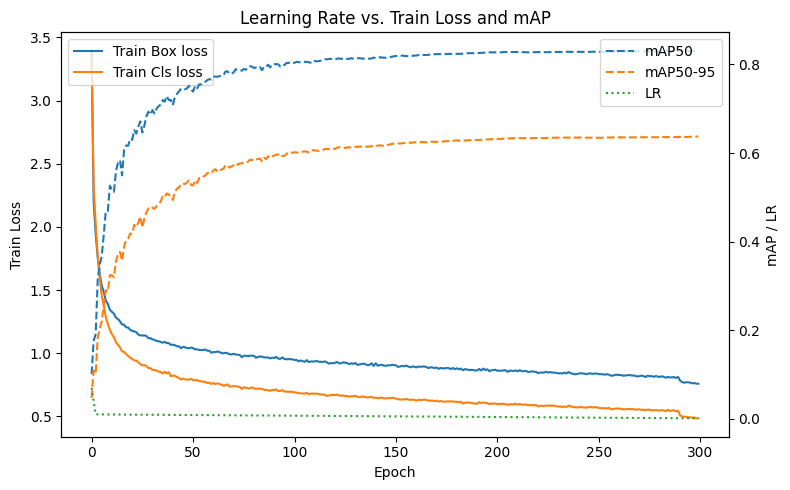

In [ ]:
# ===== Plot 1: Train Loss, mAP, LR =====
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot training losses
ax1.plot(df.index, df['train/box_loss'], label='Train Box loss')
ax1.plot(df.index, df['train/cls_loss'], label='Train Cls loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss')
ax1.legend(loc='upper left')

# Twin axis for mAP and LR
ax2 = ax1.twinx()
ax2.plot(df.index, df['metrics/mAP50(B)'], '--', label='mAP50')
ax2.plot(df.index, df['metrics/mAP50-95(B)'], '--', label='mAP50-95')
ax2.plot(df.index, df['lr/pg0'], ':', label='LR')
ax2.set_ylabel('mAP / LR')
ax2.legend(loc='upper right')

plt.title('Learning Rate vs. Train Loss and mAP')
plt.tight_layout()
plt.savefig('train_loss_vs_map_lr.png', dpi=300)
plt.show()  # Show plot 1

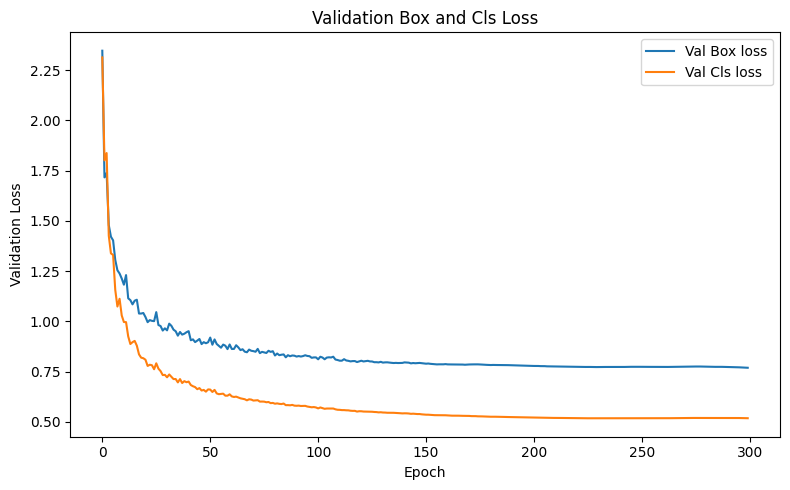

In [ ]:
# ===== Plot 2: Validation Losses =====
fig2, ax = plt.subplots(figsize=(8, 5))
ax.plot(df.index, df['val/box_loss'], label='Val Box loss')
ax.plot(df.index, df['val/cls_loss'], label='Val Cls loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.legend()
plt.title('Validation Box and Cls Loss')
plt.tight_layout()
plt.savefig('val_loss.png', dpi=300)
plt.show()  # Show plot 2

## Visualize Sample Object Detection


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/4951.jpg: 640x640 2 scallops, 1 starfish, 10.6ms
Speed: 2.1ms preprocess, 10.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


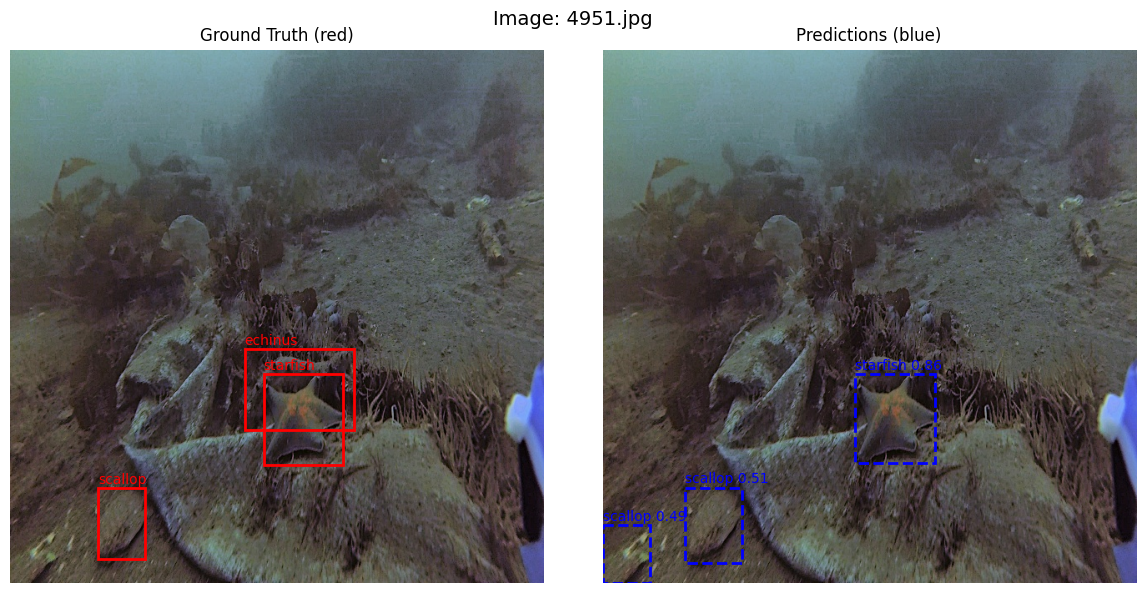


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/4971.jpg: 640x640 3 echinuss, 3 holothurians, 12.5ms
Speed: 3.1ms preprocess, 12.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


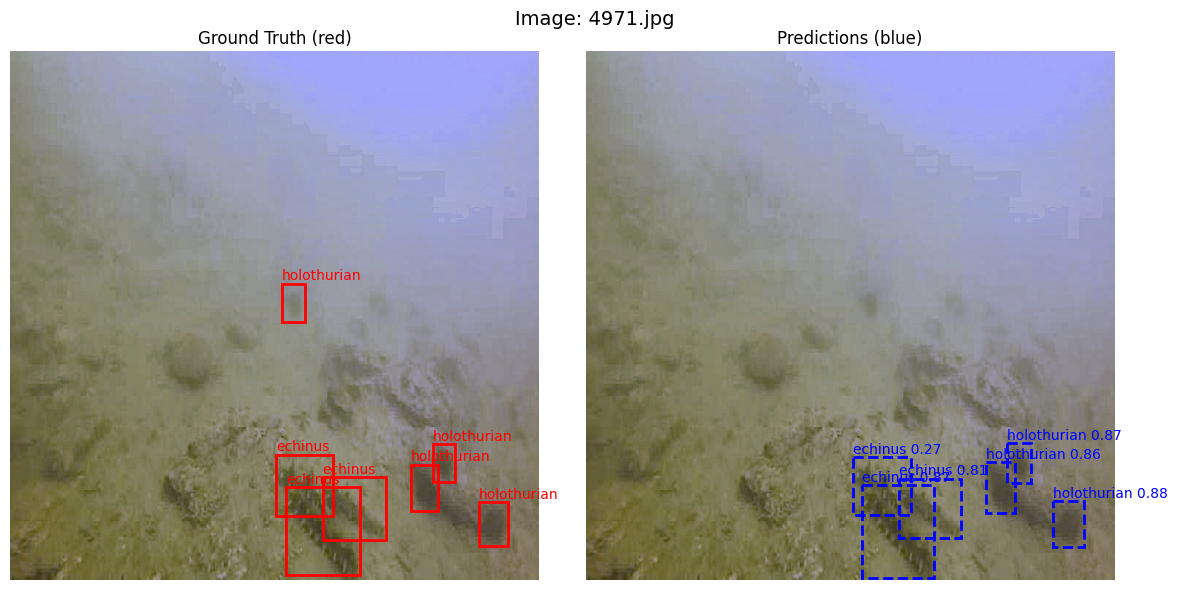


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/2126.jpg: 640x640 8 holothurians, 1 starfish, 10.0ms
Speed: 3.1ms preprocess, 10.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


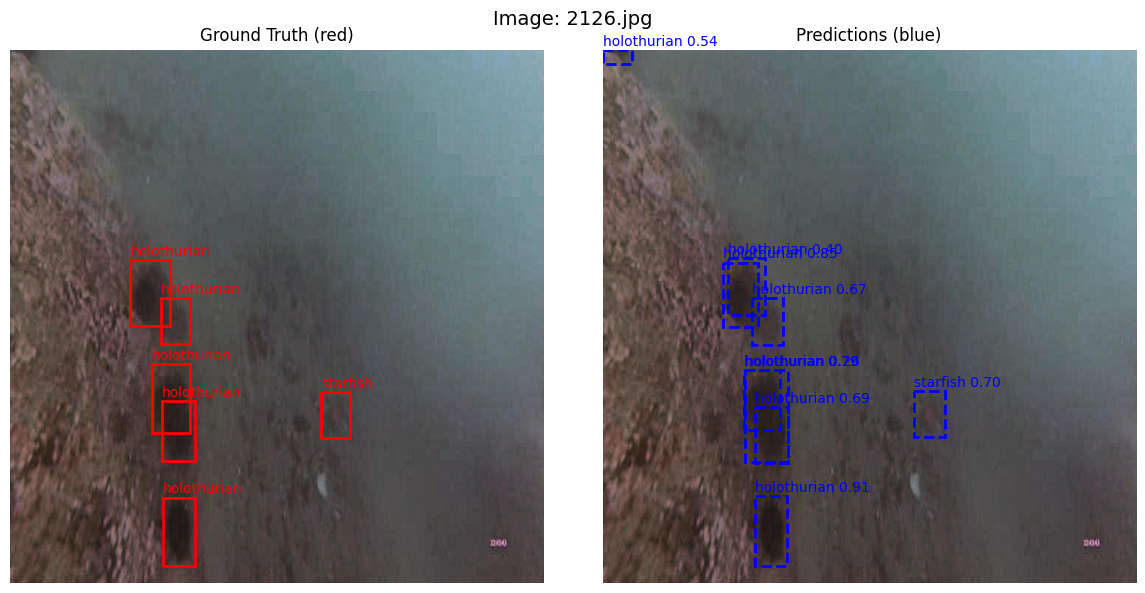


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/1355.jpg: 640x640 13 holothurians, 4 starfishs, 9.9ms
Speed: 2.0ms preprocess, 9.9ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


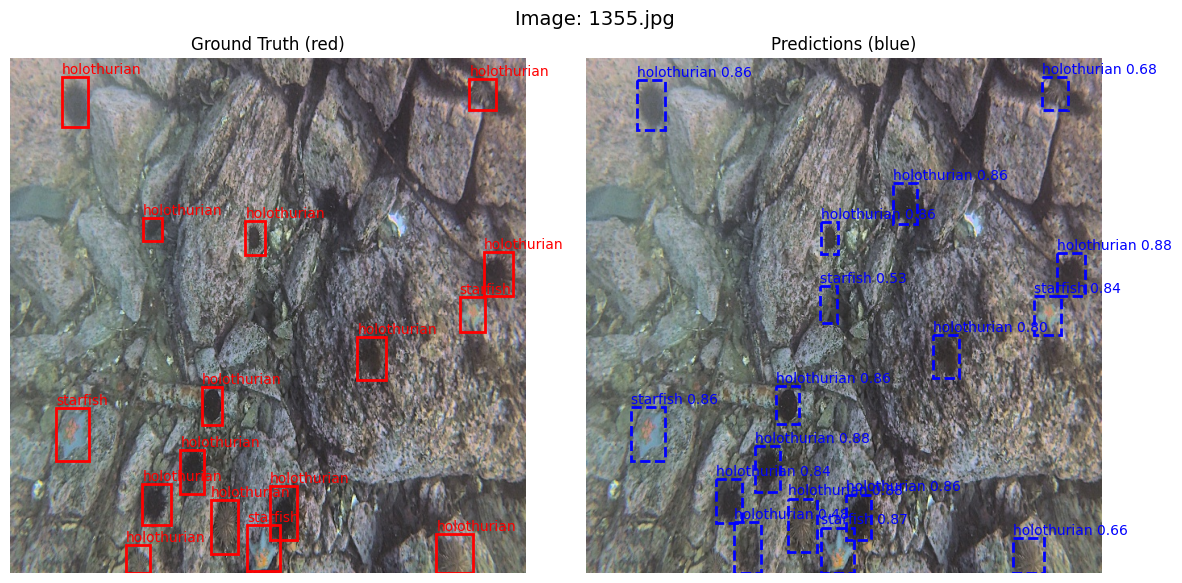


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/5247.jpg: 640x640 4 holothurians, 1 starfish, 9.9ms
Speed: 2.8ms preprocess, 9.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


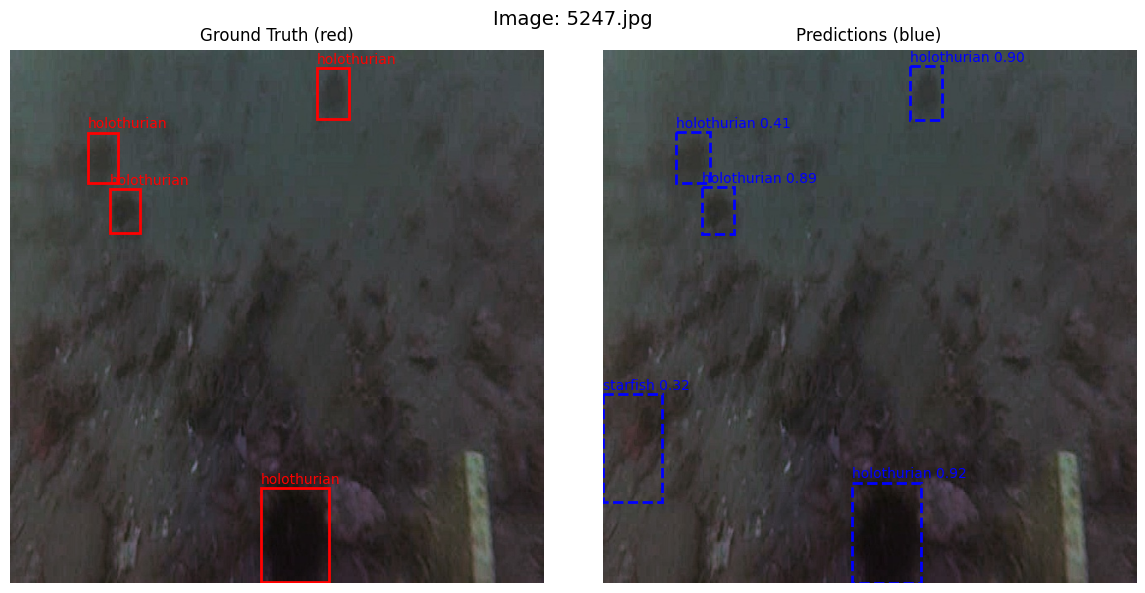

In [ ]:
test_images_dir = pathlib.Path(test_folder)
test_labels_dir = test_images_dir.parent / 'labels'

all_test_images = list(test_images_dir.glob('*.jpg')) + list(test_images_dir.glob('*.png'))
if not all_test_images:
    raise RuntimeError(f"No images found in {test_images_dir}")

N = 5
sample_images = random.sample(all_test_images, k=min(N, len(all_test_images)))

for img_path in sample_images:
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    results = best_model.predict(source=str(img_path), conf=0.25)
    preds   = results[0].boxes  # .boxes.xyxy, .boxes.cls, .boxes.conf

    label_file = test_labels_dir / f"{img_path.stem}.txt"
    gt_boxes = []
    if label_file.exists():
        with open(label_file, 'r') as f:
            for line in f:
                toks = line.split()
                if len(toks) < 5:
                    continue
                cls_id   = int(float(toks[0]))
                x_center = float(toks[1])
                y_center = float(toks[2])
                bw       = float(toks[3])
                bh       = float(toks[4])
                x_min = (x_center - bw / 2) * w
                y_min = (y_center - bh / 2) * h
                x_max = (x_center + bw / 2) * w
                y_max = (y_center + bh / 2) * h
                gt_boxes.append((int(x_min), int(y_min), int(x_max), int(y_max), cls_id))
    else:
        print(f"⚠️ Warning: No label file for {img_path.name}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax_gt, ax_pred = axes[0], axes[1]

    ax_gt.imshow(img_rgb)
    ax_gt.set_title("Ground Truth (red)")
    ax_gt.axis('off')
    for (xmin, ymin, xmax, ymax, cls_id) in gt_boxes:
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor='red',
            facecolor='none',
            linestyle='-'
        )
        ax_gt.add_patch(rect)
        ax_gt.text(
            xmin,
            ymin - 5,
            f"{best_model.names[cls_id]}",
            color='red',
            fontsize=10
        )

    ax_pred.imshow(img_rgb)
    ax_pred.set_title("Predictions (blue)")
    ax_pred.axis('off')
    for box in preds:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls_id = int(box.cls.cpu().numpy()[0])
        conf   = float(box.conf.cpu().numpy()[0])
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='blue',
            facecolor='none',
            linestyle='--'
        )
        ax_pred.add_patch(rect)
        ax_pred.text(
            x1,
            y1 - 5,
            f"{best_model.names[cls_id]} {conf:.2f}",
            color='blue',
            fontsize=10
        )

    plt.suptitle(f"Image: {img_path.name}", fontsize=14)
    plt.tight_layout()
    plt.show()



image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/695.jpg: 640x640 4 echinuss, 4 holothurians, 1 scallop, 8 starfishs, 9.8ms
Speed: 2.7ms preprocess, 9.8ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


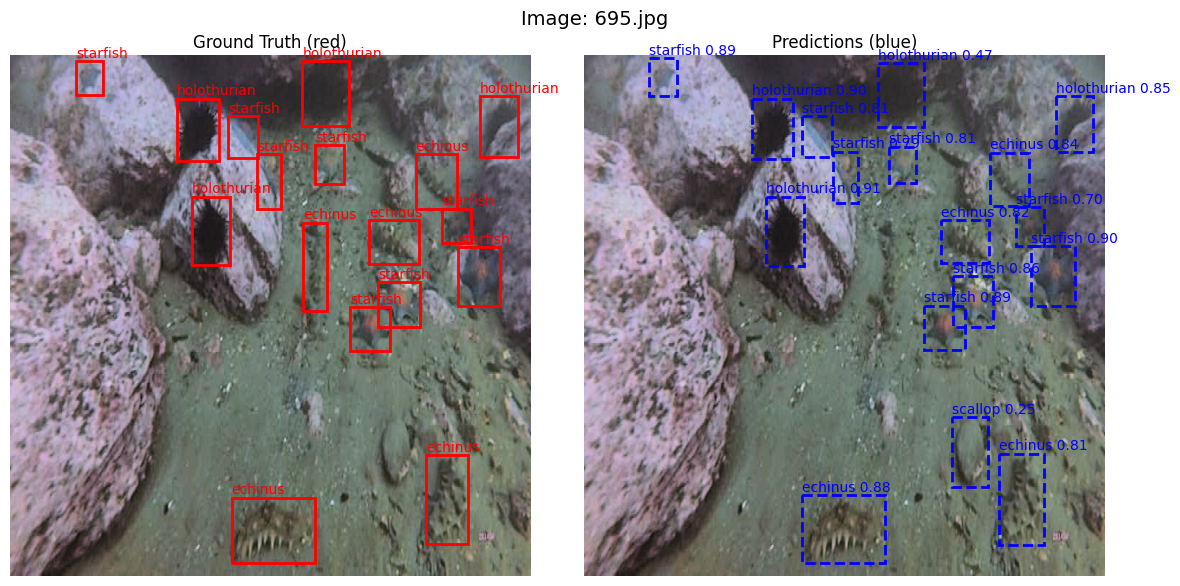


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/436.jpg: 640x640 4 holothurians, 1 starfish, 10.9ms
Speed: 3.0ms preprocess, 10.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


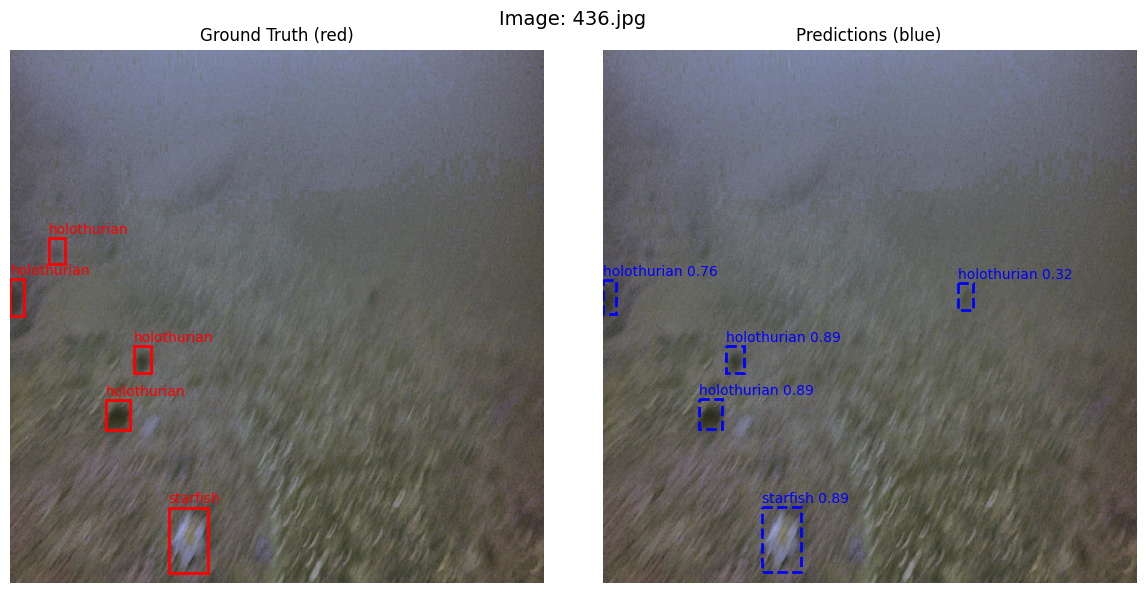


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/5320.jpg: 640x640 3 echinuss, 2 starfishs, 12.3ms
Speed: 3.6ms preprocess, 12.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


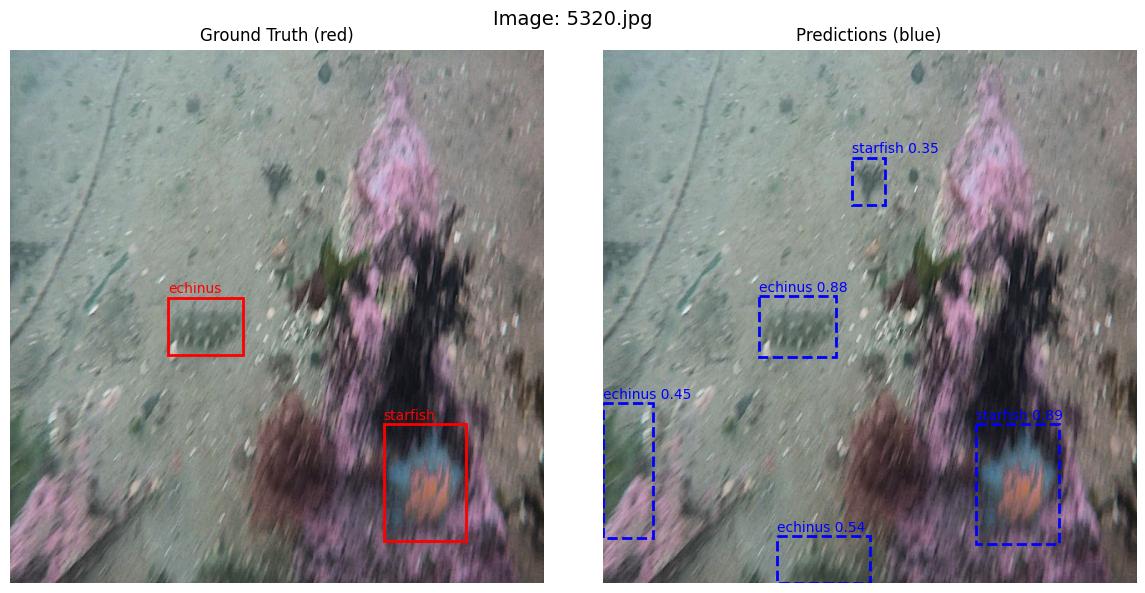


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/5922.jpg: 640x640 7 holothurians, 1 starfish, 10.2ms
Speed: 2.8ms preprocess, 10.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


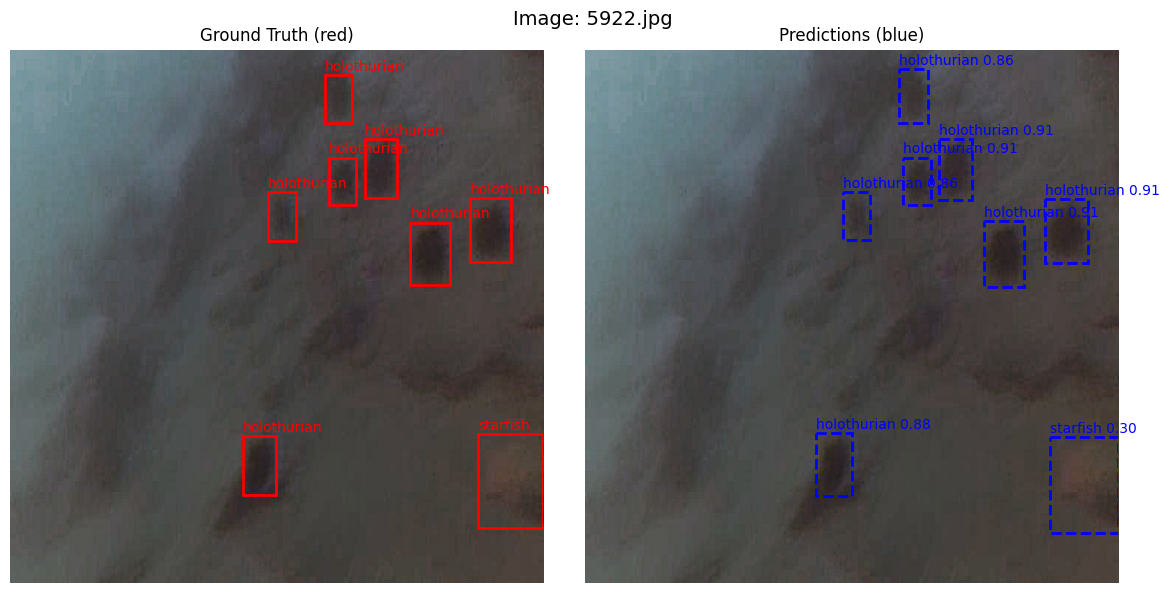


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/1878.jpg: 640x640 5 holothurians, 9.7ms
Speed: 2.7ms preprocess, 9.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


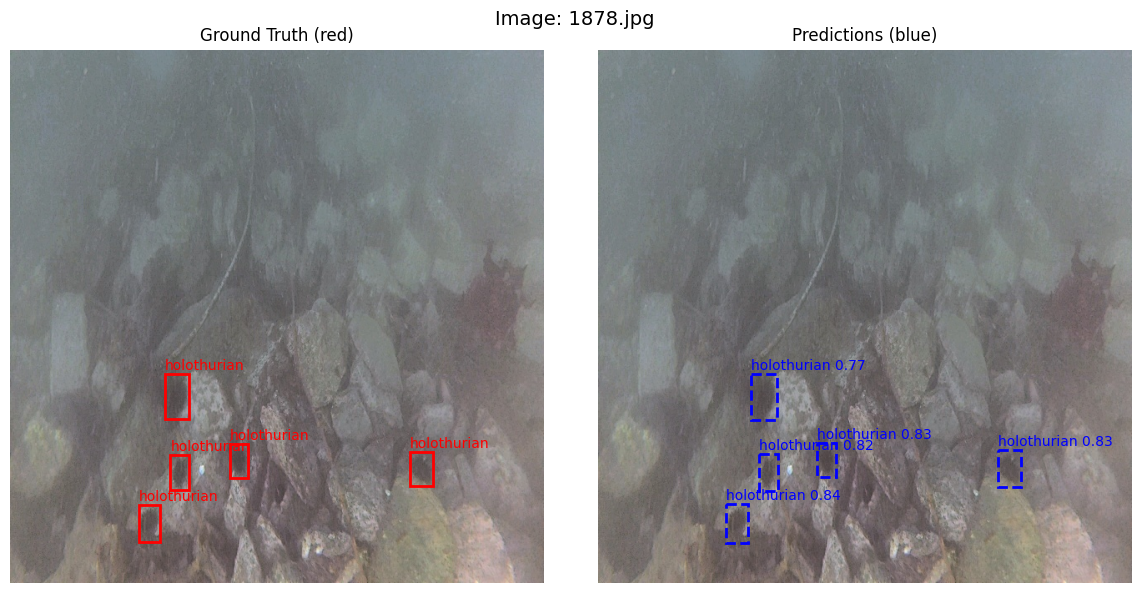

In [ ]:
output_dir = Path("sample_visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

N = 5
sample_images = random.sample(all_test_images, k=min(N, len(all_test_images)))

for img_path in sample_images:
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    results = best_model.predict(source=str(img_path), conf=0.25)
    preds   = results[0].boxes

    label_file = test_labels_dir / f"{img_path.stem}.txt"
    gt_boxes = []
    if label_file.exists():
        with open(label_file, 'r') as f:
            for line in f:
                toks = line.split()
                if len(toks) < 5:
                    continue
                cls_id   = int(float(toks[0]))
                x_center = float(toks[1])
                y_center = float(toks[2])
                bw       = float(toks[3])
                bh       = float(toks[4])
                x_min = (x_center - bw / 2) * w
                y_min = (y_center - bh / 2) * h
                x_max = (x_center + bw / 2) * w
                y_max = (y_center + bh / 2) * h
                gt_boxes.append((int(x_min), int(y_min), int(x_max), int(y_max), cls_id))
    else:
        print(f"⚠️ Warning: No label file for {img_path.name}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax_gt, ax_pred = axes[0], axes[1]

    ax_gt.imshow(img_rgb)
    ax_gt.set_title("Ground Truth (red)")
    ax_gt.axis('off')
    for (xmin, ymin, xmax, ymax, cls_id) in gt_boxes:
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax_gt.add_patch(rect)
        ax_gt.text(xmin, ymin - 5, f"{best_model.names[cls_id]}", color='red', fontsize=10)

    ax_pred.imshow(img_rgb)
    ax_pred.set_title("Predictions (blue)")
    ax_pred.axis('off')
    for box in preds:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls_id = int(box.cls.cpu().numpy()[0])
        conf   = float(box.conf.cpu().numpy()[0])
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
        ax_pred.add_patch(rect)
        ax_pred.text(x1, y1 - 5, f"{best_model.names[cls_id]} {conf:.2f}", color='blue', fontsize=10)

    plt.suptitle(f"Image: {img_path.name}", fontsize=14)
    plt.tight_layout()

    # ✅ Save the figure
    output_path = output_dir / f"{img_path.stem}_gt_vs_pred.png"
    plt.savefig(output_path, dpi=300)
    plt.show()


## Export Prediction Results as CSV

In [ ]:
# ---- Export Prediction Results ----
prediction_data = []
for img_path in all_test_images:
    results = best_model.predict(source=str(img_path), conf=0.25)
    preds = results[0].boxes
    for box in preds:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls.cpu().numpy()[0])
        conf = float(box.conf.cpu().numpy()[0])
        prediction_data.append({
            "Image": img_path.name,
            "Class ID": cls_id,
            "Class Name": best_model.names[cls_id],
            "Confidence": conf,
            "X1": x1,
            "Y1": y1,
            "X2": x2,
            "Y2": y2
        })
df_preds = pd.DataFrame(prediction_data)
df_preds.to_csv("prediction_results.csv", index=False)
print("✅ Exported prediction_results.csv")


image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/5824.jpg: 640x640 5 holothurians, 2 starfishs, 10.5ms
Speed: 2.1ms preprocess, 10.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/978.jpg: 640x640 14 holothurians, 10.3ms
Speed: 1.9ms preprocess, 10.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/1266.jpg: 640x640 1 echinus, 13 holothurians, 5 starfishs, 10.1ms
Speed: 2.0ms preprocess, 10.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/4449.jpg: 640x640 3 echinuss, 1 holothurian, 9.8ms
Speed: 2.0ms preprocess, 9.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/DUO-dataset-2/content/DUO-dat

## Export Results as Zip

In [ ]:
import datetime
from zipfile import ZipFile

# === Define dynamic export folder name based on YAML + timestamp ===
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
clean_dataset = DATASET_TYPE.replace(" ", "_")
export_name = f"{model_name}_{clean_dataset}_{timestamp}"
export_dir = Path(export_name)
export_dir.mkdir(parents=True, exist_ok=True)

# === List of files to export ===
export_files = [
    "cm_test.csv",
    "per_class_metrics.csv",
    "train_loss_vs_map_lr.png",
    "val_loss.png",
    "model_summary.txt",
    "test_metrics.txt",
    "prediction_results.csv",
    yaml_path
]
# === Copy export files into the export folder ===
for file in export_files:
    src = Path(file)
    dst = export_dir / f"{src.stem}_{export_name}{src.suffix}"
    shutil.copy(src, dst)

# === Copy best.pt and last.pt directly to the root of export folder ===
weights_dir = Path("/content/HaYOLO/runs/detect/train/weights")
for weight_name in ["best.pt", "last.pt"]:
    weight_path = weights_dir / weight_name
    if weight_path.exists():
        weight_stem = Path(weight_name).stem
        weight_suffix = Path(weight_name).suffix
        renamed = f"{weight_stem}_{export_name}{weight_suffix}"
        shutil.copy(weight_path, export_dir / renamed)

# === Copy sample visualizations ===
sample_vis_dir = Path("sample_visualizations")
sample_vis_export = export_dir / f"sample_visualizations_{export_name}"
shutil.copytree(sample_vis_dir, sample_vis_export)

# === Copy HaYOLO runs/detect directory ===
detect_src = Path("/content/HaYOLO/runs/detect")
detect_dst = export_dir / f"detect_outputs_{export_name}"
shutil.copytree(detect_src, detect_dst)

# === Zip the export directory ===
zip_filename = f"{export_name}.zip"
shutil.make_archive(base_name=export_name, format='zip', root_dir=export_dir)
print(f"✅ Zipped everything into {zip_filename}")


✅ Zipped everything into yolov11n_CBAM_ENHANCED_HILMI_2025-06-24_12-05-46.zip


### Download From Google Colab

In [ ]:
from google.colab import files
files.download(f"{zip_filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Put in Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

drive_export_dir = Path("/content/drive/MyDrive/FinalYoloExports")
drive_export_dir.mkdir(parents=True, exist_ok=True)

shutil.copy(f"{zip_filename}", drive_export_dir / zip_filename)
print(f"✅ Copied {zip_filename} to Google Drive at {drive_export_dir}")

Mounted at /content/drive
✅ Copied yolov11n_CBAM_ENHANCED_HILMI_2025-06-24_12-05-46.zip to Google Drive at /content/drive/MyDrive/FinalYoloExports
